<a href="https://colab.research.google.com/github/nmquintero/MLandDS/blob/main/Unsupervised%20Learning%20Foundations%20and%20Clustering/Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning

## Configuración del entorno
### Nicolas Maurucio Quintero Hernandez

In [ ]:
# === DEPENDENCIAS ===
# Local (Jupyter): descomenta y ejecuta una vez si es necesario
# !pip install scikit-learn-extra

# Google Colab: instalacion y reinicio automatico
import sys
if "google.colab" in sys.modules:
    import importlib.util, subprocess
    if importlib.util.find_spec("sklearn_extra") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn-extra"])
        print("scikit-learn-extra instalado. Reiniciando kernel...")
        from google.colab.output import eval_js
        eval_js("google.colab.kernel.restartSession()")

import pandas as pd
import numpy as np
import matplotlib
import seaborn
import sklearn
import scipy
print("Entorno listo.")

Entorno listo.


## 1. K-Means Clustering

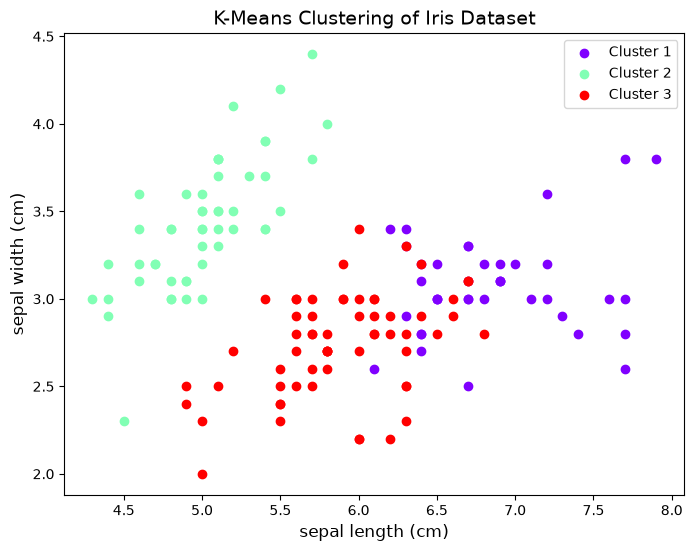

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)

kmeans = KMeans(n_clusters=3, random_state=42)
iris_data['Cluster'] = kmeans.fit_predict(iris_data)

plt.figure(figsize=(8, 6))
colors = cm.rainbow(np.linspace(0, 1, 3))
for i, color in enumerate(colors):
    cluster_data = iris_data[iris_data['Cluster'] == i]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f'Cluster {i+1}', color=color)

plt.title('K-Means Clustering of Iris Dataset', fontsize=14)
plt.xlabel(iris.feature_names[0], fontsize=12)
plt.ylabel(iris.feature_names[1], fontsize=12)
plt.legend()
plt.show()

## 2. K-Medoids Clustering

In [ ]:
# scikit-learn-extra se instala en la celda 1

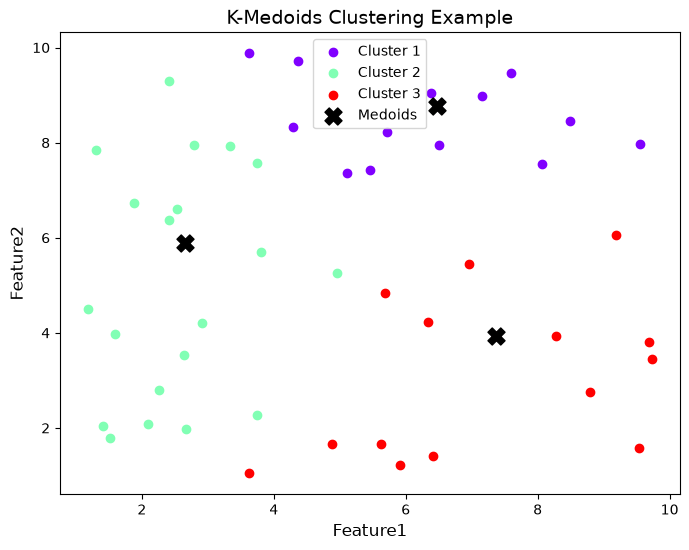

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn_extra.cluster import KMedoids
import numpy as np

np.random.seed(42)
data = pd.DataFrame({
    'Feature1': np.random.uniform(1, 10, 50),
    'Feature2': np.random.uniform(1, 10, 50)
})

kmedoids = KMedoids(n_clusters=3, random_state=42, metric='euclidean')
data['Cluster'] = kmedoids.fit_predict(data)

plt.figure(figsize=(8, 6))
colors = cm.rainbow(np.linspace(0, 1, 3))
for i, color in enumerate(colors):
    cluster_data = data[data['Cluster'] == i]
    plt.scatter(cluster_data['Feature1'], cluster_data['Feature2'], label=f'Cluster {i+1}', color=color)

medoid_points = data.iloc[kmedoids.medoid_indices_]
plt.scatter(medoid_points['Feature1'], medoid_points['Feature2'], c='black', s=150, label='Medoids', marker='X')

plt.title('K-Medoids Clustering Example', fontsize=14)
plt.xlabel('Feature1', fontsize=12)
plt.ylabel('Feature2', fontsize=12)
plt.legend()
plt.show()

## 3. Comparing KMedoids and CLARA

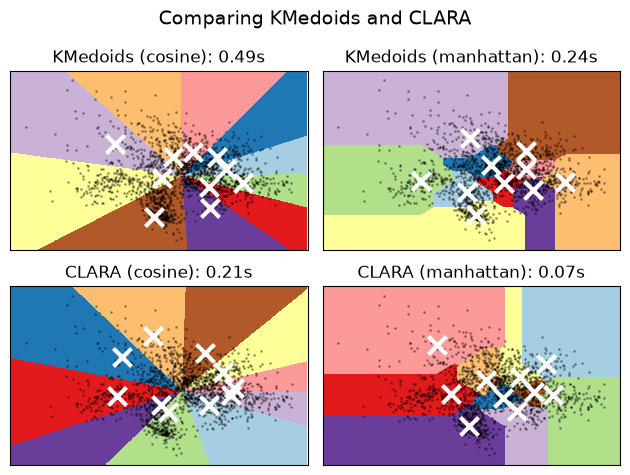

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn_extra.cluster import KMedoids, CLARA
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

np.random.seed(42)
digits = load_digits()
data = scale(digits.data)
n_digits = len(np.unique(digits.target))
reduced_data = PCA(n_components=2).fit_transform(data)

h = 0.02
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure(); plt.clf()
plt.suptitle("Comparing KMedoids and CLARA", fontsize=14)

selected_models = [
    (KMedoids(metric="cosine", n_clusters=n_digits), "KMedoids (cosine)"),
    (KMedoids(metric="manhattan", n_clusters=n_digits), "KMedoids (manhattan)"),
    (CLARA(metric="cosine", n_clusters=n_digits, init="heuristic", n_sampling=50), "CLARA (cosine)"),
    (CLARA(metric="manhattan", n_clusters=n_digits, init="heuristic", n_sampling=50), "CLARA (manhattan)"),
]

for i, (model, description) in enumerate(selected_models):
    t0 = time.time()
    model.fit(reduced_data)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    elapsed = time.time() - t0
    plt.subplot(2, 2, i + 1)
    plt.imshow(Z, interpolation="nearest",
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Paired, aspect="auto", origin="lower")
    plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2, alpha=0.3)
    centroids = model.cluster_centers_
    plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=169, linewidths=3, color="w", zorder=10)
    plt.title(f"{description}: {elapsed:.2f}s")
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.xticks(()); plt.yticks(())

plt.tight_layout()
plt.show()

## 4. DBSCAN Clustering

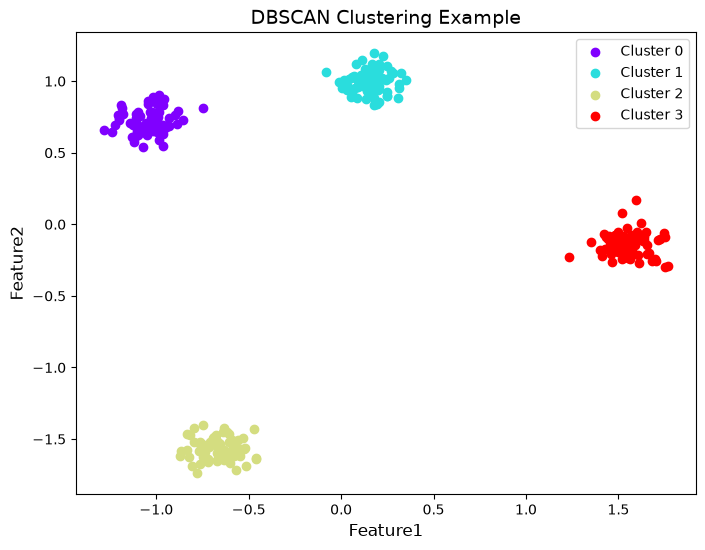

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
data, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=42)
data = StandardScaler().fit_transform(data)

clusters = DBSCAN(eps=0.3, min_samples=5).fit_predict(data)

df = pd.DataFrame(data, columns=['Feature1', 'Feature2'])
df['Cluster'] = clusters

plt.figure(figsize=(8, 6))
unique_clusters = set(clusters)
colors = cm.rainbow(np.linspace(0, 1, len(unique_clusters)))
for cluster, color in zip(unique_clusters, colors):
    cd = df[df['Cluster'] == cluster]
    plt.scatter(cd['Feature1'], cd['Feature2'],
                label=f'Cluster {cluster}' if cluster != -1 else 'Noise', color=color)

plt.title('DBSCAN Clustering Example', fontsize=14)
plt.xlabel('Feature1', fontsize=12); plt.ylabel('Feature2', fontsize=12)
plt.legend(); plt.show()

## 5. Hierarchical Clustering

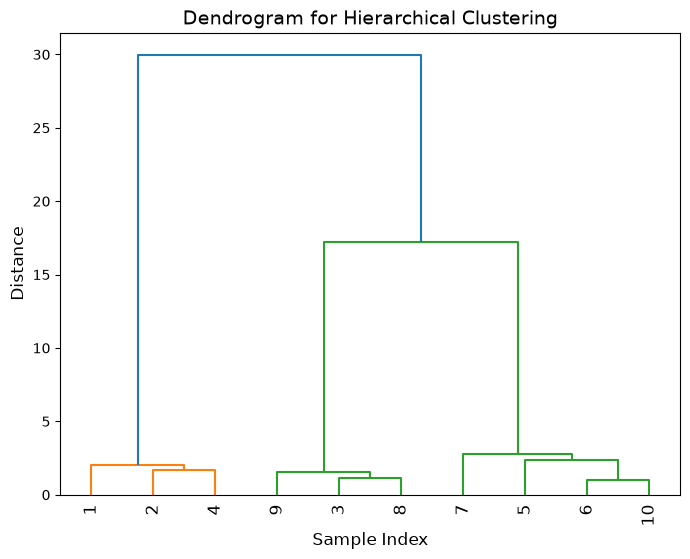

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

np.random.seed(42)
data, _ = make_blobs(n_samples=10, centers=3, cluster_std=1, random_state=42)

linkage_matrix = linkage(data, method='ward')

plt.figure(figsize=(8, 6))
dendrogram(linkage_matrix, labels=range(1, len(data) + 1), leaf_rotation=90)
plt.title("Dendrogram for Hierarchical Clustering", fontsize=14)
plt.xlabel("Sample Index", fontsize=12); plt.ylabel("Distance", fontsize=12)
plt.show()

## 6. Gaussian Mixture Model (GMM)

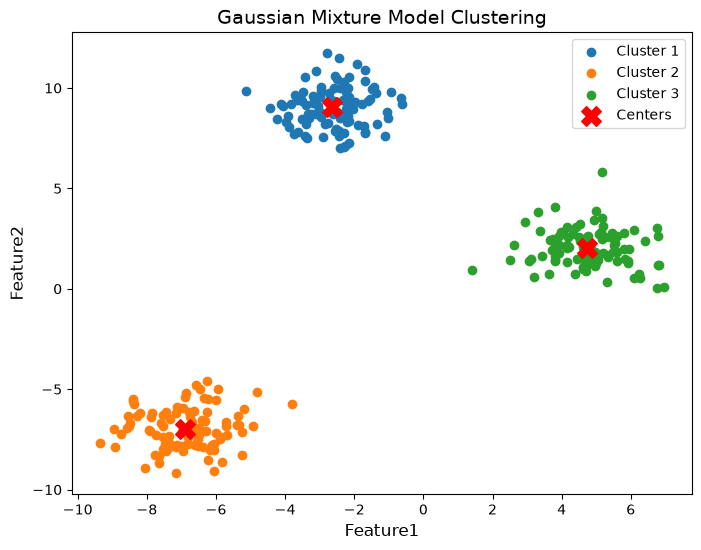

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

np.random.seed(42)
data, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
df = pd.DataFrame(data, columns=['Feature1', 'Feature2'])

gmm = GaussianMixture(n_components=3, random_state=42)
df['Cluster'] = gmm.fit_predict(data)

plt.figure(figsize=(8, 6))
for cluster in range(3):
    cd = df[df['Cluster'] == cluster]
    plt.scatter(cd['Feature1'], cd['Feature2'], label=f'Cluster {cluster+1}')

centers = gmm.means_
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label='Centers')
plt.title('Gaussian Mixture Model Clustering', fontsize=14)
plt.xlabel('Feature1', fontsize=12); plt.ylabel('Feature2', fontsize=12)
plt.legend(); plt.show()

## 7. PCA for Dimensionality Reduction (sklearn)

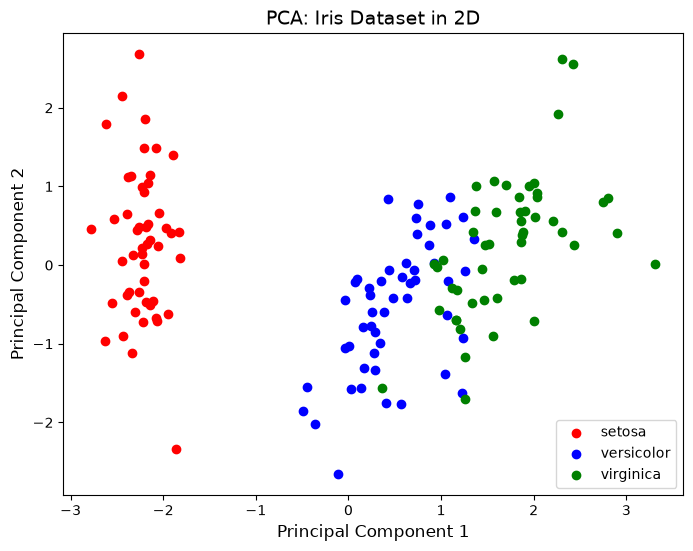

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
data_scaled = StandardScaler().fit_transform(iris.data)

data_pca = PCA(n_components=2).fit_transform(data_scaled)
pca_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = iris.target

plt.figure(figsize=(8, 6))
for target, color in zip(np.unique(iris.target), ['red', 'blue', 'green']):
    s = pca_df[pca_df['Target'] == target]
    plt.scatter(s['PC1'], s['PC2'], label=iris.target_names[target], color=color)

plt.title('PCA: Iris Dataset in 2D', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12); plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(); plt.show()

## 8. PCA Manual (Breast Cancer Dataset)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
print('Original Dataframe shape :', df.shape)
X = df[cancer['feature_names']]
print('Inputs Dataframe shape   :', X.shape)

Original Dataframe shape : (569, 31)
Inputs Dataframe shape   : (569, 30)


In [ ]:
X_mean = X.mean()
X_std = X.std()
Z = (X - X_mean) / X_std

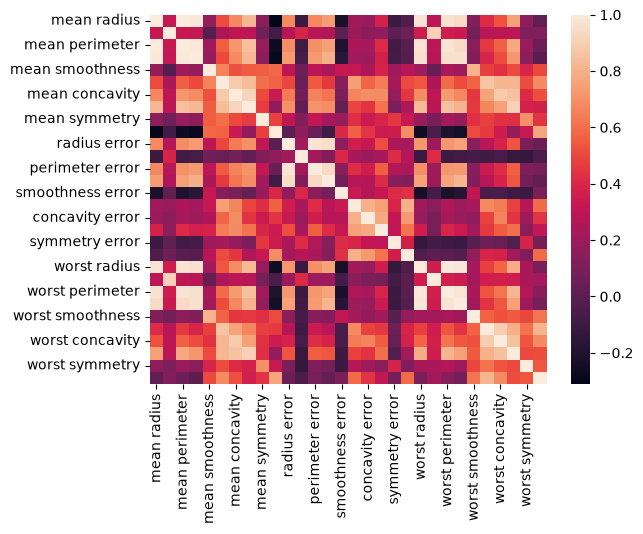

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
c = Z.cov()
sns.heatmap(c)
plt.show()

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(c)
print('Eigen values:\n', eigenvalues)
print('Shape:', eigenvalues.shape, eigenvectors.shape)

Eigen values:
 [1.32816077e+01 5.69135461e+00 2.81794898e+00 1.98064047e+00
 1.64873055e+00 1.20735661e+00 6.75220114e-01 4.76617140e-01
 4.16894812e-01 3.50693457e-01 2.93915696e-01 2.61161370e-01
 2.41357496e-01 1.57009724e-01 9.41349650e-02 7.98628010e-02
 5.93990378e-02 5.26187835e-02 4.94775918e-02 1.33044823e-04
 7.48803097e-04 1.58933787e-03 6.90046388e-03 8.17763986e-03
 1.54812714e-02 1.80550070e-02 2.43408378e-02 2.74394025e-02
 3.11594025e-02 2.99728939e-02]
Shape: (30,) (30, 30)


In [ ]:
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [ ]:
explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
explained_var

array([0.44272026, 0.63243208, 0.72636371, 0.79238506, 0.84734274,
       0.88758796, 0.9100953 , 0.92598254, 0.93987903, 0.95156881,
       0.961366  , 0.97007138, 0.97811663, 0.98335029, 0.98648812,
       0.98915022, 0.99113018, 0.99288414, 0.9945334 , 0.99557204,
       0.99657114, 0.99748579, 0.99829715, 0.99889898, 0.99941502,
       0.99968761, 0.99991763, 0.99997061, 0.99999557, 1.        ])

In [ ]:
n_components = np.argmax(explained_var >= 0.50) + 1
n_components

np.int64(2)

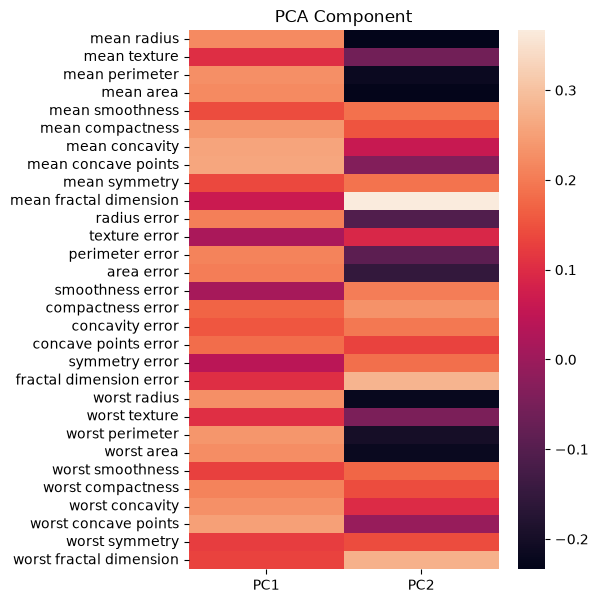

In [ ]:
u = eigenvectors[:, :n_components]
pca_component = pd.DataFrame(u, index=cancer['feature_names'], columns=['PC1', 'PC2'])
plt.figure(figsize=(5, 7))
sns.heatmap(pca_component)
plt.title('PCA Component')
plt.show()

## 9. LDA for Dimensionality Reduction

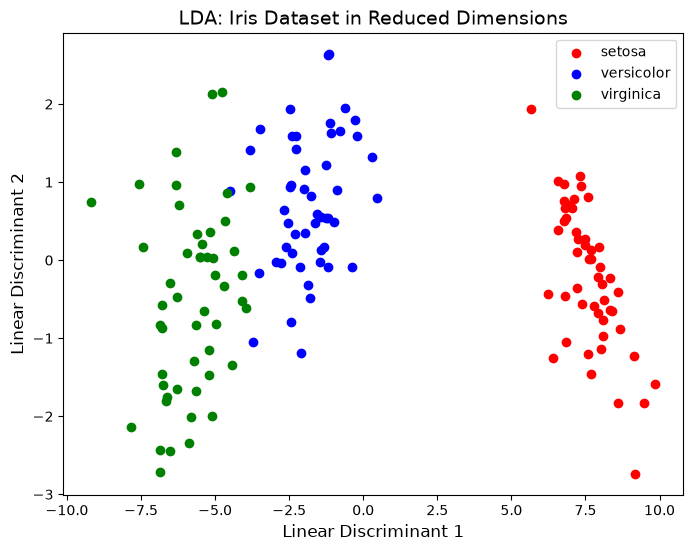

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris

iris = load_iris()
X, y, class_names = iris.data, iris.target, iris.target_names

X_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Target'] = y

plt.figure(figsize=(8, 6))
for target, color in zip(np.unique(y), ['red', 'blue', 'green']):
    s = lda_df[lda_df['Target'] == target]
    plt.scatter(s['LD1'], s['LD2'], label=class_names[target], color=color)

plt.title('LDA: Iris Dataset in Reduced Dimensions', fontsize=14)
plt.xlabel('Linear Discriminant 1', fontsize=12); plt.ylabel('Linear Discriminant 2', fontsize=12)
plt.legend(); plt.show()

## 10. Non-negative Matrix Factorization (NMF)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "The cat sat on the mat",
    "The dog barked at the mailman",
    "Cats and dogs are common pets",
    "The mat was made of wool",
    "Mailmen often bring packages"
]

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

nmf = NMF(n_components=2, random_state=42)
W = nmf.fit_transform(tfidf_matrix)
H = nmf.components_

terms = vectorizer.get_feature_names_out()
topics = pd.DataFrame(H, columns=terms)
topics.index = [f'Topic {i+1}' for i in range(H.shape[0])]
print("Top words in each topic:")
print(topics)

doc_topics = pd.DataFrame(W, columns=[f'Topic {i+1}' for i in range(W.shape[1])])
doc_topics['Document'] = documents
print("\nDocument-topic matrix:")
print(doc_topics)

Top words in each topic:
           barked     bring       cat      cats    common       dog      dogs  \
Topic 1  0.000024  0.000000  0.479345  0.000067  0.000067  0.000024  0.000067   
Topic 2  0.091291  0.556709  0.000000  0.088005  0.088005  0.091291  0.088005   

          mailman   mailmen       mat  packages      pets       sat      wool  
Topic 1  0.000024  0.000000  0.876789  0.000000  0.000067  0.479345  0.607412  
Topic 2  0.091291  0.556709  0.000000  0.556709  0.088005  0.000000  0.000000  

Document-topic matrix:
    Topic 1   Topic 2                       Document
0  0.640654  0.000000         The cat sat on the mat
1  0.000038  0.160405  The dog barked at the mailman
2  0.000115  0.178553  Cats and dogs are common pets
3  0.640654  0.000000       The mat was made of wool
4  0.000000  0.978182   Mailmen often bring packages


## 11. Locally Linear Embedding (LLE)

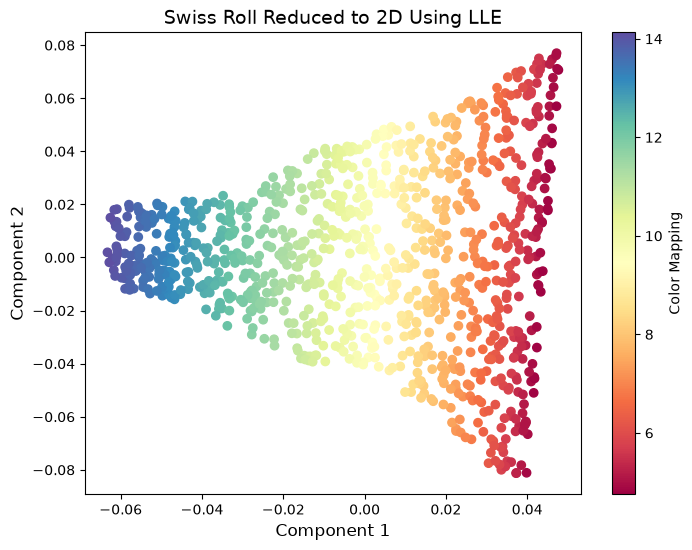

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

np.random.seed(42)
data, color = make_swiss_roll(n_samples=1000, noise=0.1)

data_lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=42).fit_transform(data)

plt.figure(figsize=(8, 6))
plt.scatter(data_lle[:, 0], data_lle[:, 1], c=color, cmap=plt.cm.Spectral)
plt.title("Swiss Roll Reduced to 2D Using LLE", fontsize=14)
plt.xlabel("Component 1", fontsize=12); plt.ylabel("Component 2", fontsize=12)
plt.colorbar(label="Color Mapping"); plt.show()

## 12. Isomap

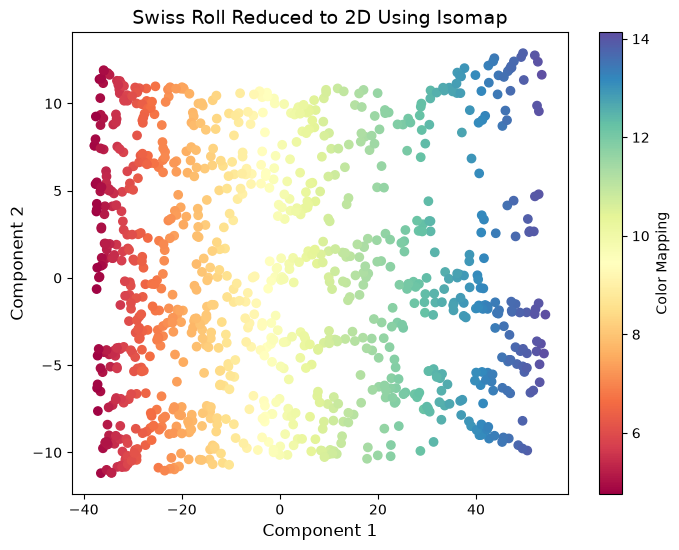

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap

np.random.seed(42)
data, color = make_swiss_roll(n_samples=1000, noise=0.1)

data_isomap = Isomap(n_neighbors=10, n_components=2).fit_transform(data)

plt.figure(figsize=(8, 6))
plt.scatter(data_isomap[:, 0], data_isomap[:, 1], c=color, cmap=plt.cm.Spectral)
plt.title("Swiss Roll Reduced to 2D Using Isomap", fontsize=14)
plt.xlabel("Component 1", fontsize=12); plt.ylabel("Component 2", fontsize=12)
plt.colorbar(label="Color Mapping"); plt.show()

## 13. t-SNE Visualization

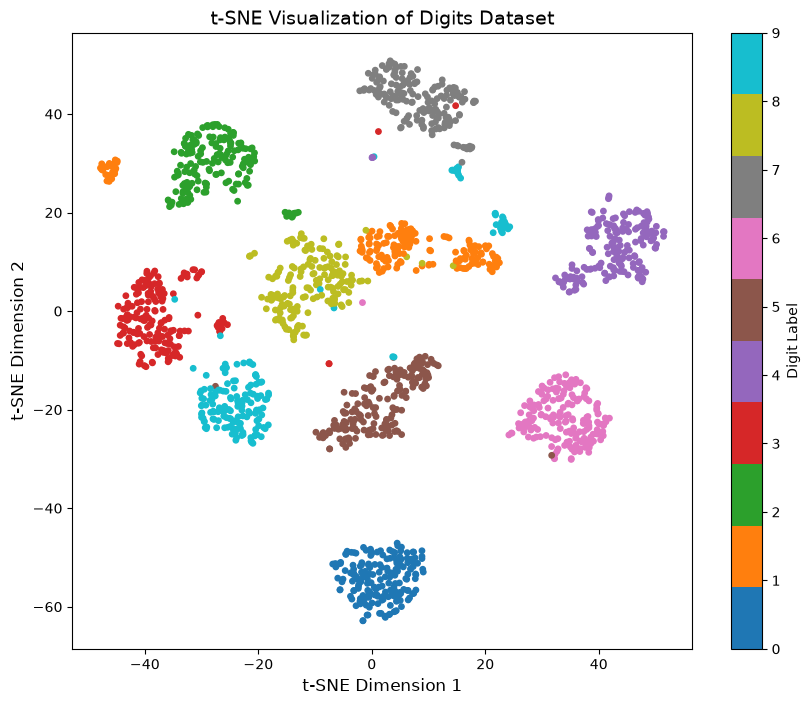

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

digits = load_digits()
data_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(digits.data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=digits.target, cmap=plt.cm.tab10, s=15)
plt.colorbar(scatter, label="Digit Label")
plt.title("t-SNE Visualization of Digits Dataset", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12); plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.show()